In [8]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

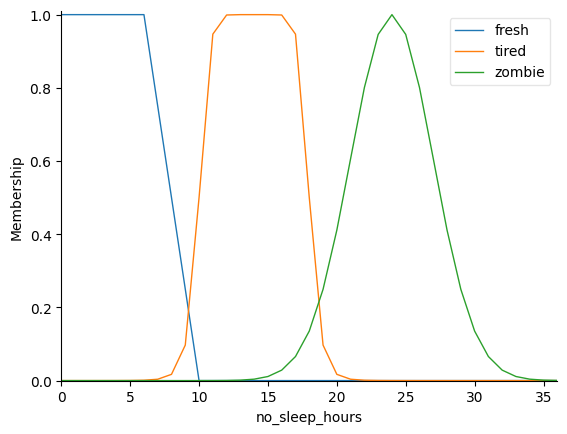

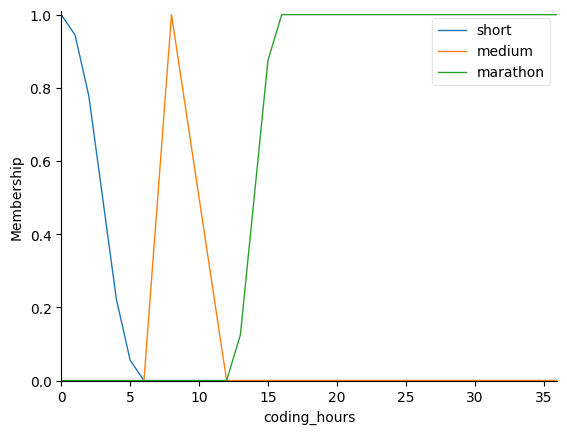

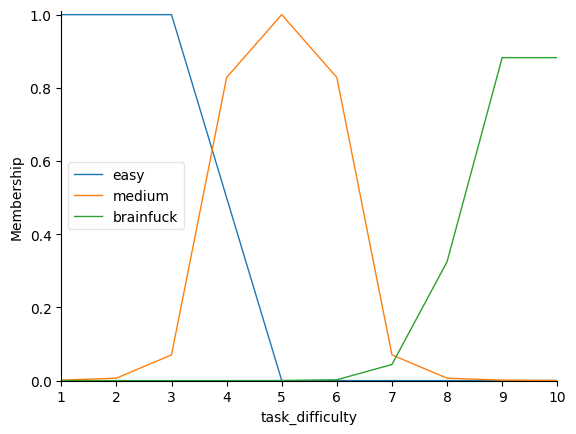

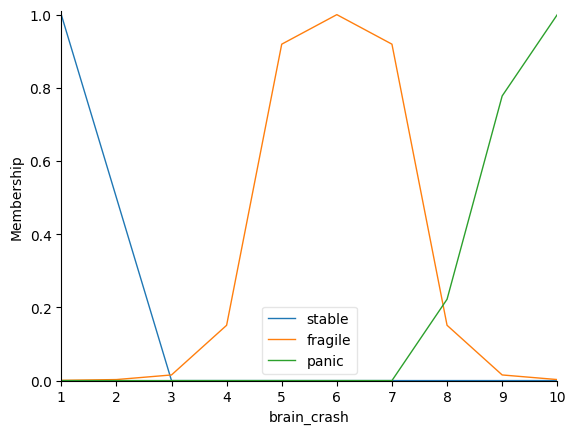

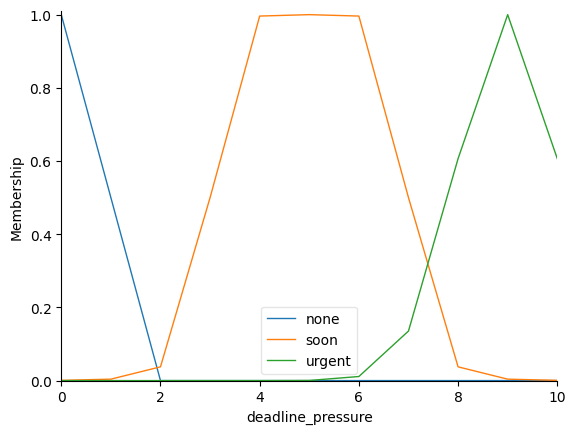

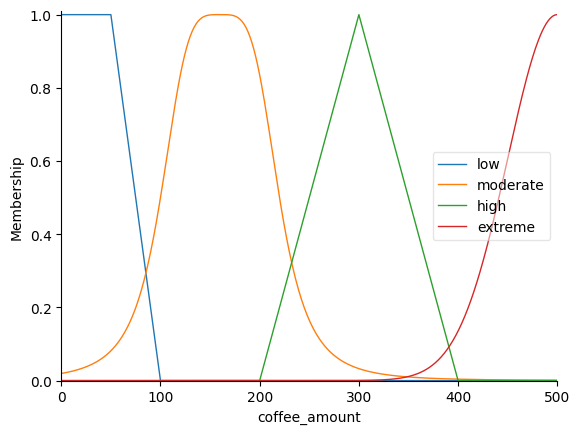

In [9]:
# === Вхідні змінні ===
no_sleep_hours = ctrl.Antecedent(np.arange(0, 37, 1), 'no_sleep_hours')
coding_hours = ctrl.Antecedent(np.arange(0, 37, 1), 'coding_hours')
task_difficulty = ctrl.Antecedent(np.arange(1, 11, 1), 'task_difficulty')
brain_crash = ctrl.Antecedent(np.arange(1, 11, 1), 'brain_crash')
deadline_pressure = ctrl.Antecedent(np.arange(0, 11, 1), 'deadline_pressure')

# === Вихідна змінна ===
coffee_amount = ctrl.Consequent(np.arange(0, 501, 1), 'coffee_amount')

# === no_sleep_hours: скільки годин не спав ===
# trapmf — бо від 0 до 6 людина майже повністю "свіжа", а потім поступово втома
no_sleep_hours['fresh'] = fuzz.trapmf(no_sleep_hours.universe, [0, 0, 6, 10])
# gbellmf — плавний "перехід" в режим втоми
no_sleep_hours['tired'] = fuzz.gbellmf(no_sleep_hours.universe, 4, 5, 14)
# gaussmf — вхід у зомбі-режим чітко центрується десь на 24
no_sleep_hours['zombie'] = fuzz.gaussmf(no_sleep_hours.universe, 24, 3)
no_sleep_hours.view()

# === coding_hours: скільки годин кодиш ===
# zmf — плавний перехід від "початківця" до "в потоці"
coding_hours['short'] = fuzz.zmf(coding_hours.universe, 0, 6)
# trimf — бо це нормальна "середина"
coding_hours['medium'] = fuzz.trimf(coding_hours.universe, [6, 8, 12])
# smf — виснаження після 12+ годин коду
coding_hours['marathon'] = fuzz.smf(coding_hours.universe, 12, 16)
coding_hours.view()
# === task_difficulty: складність задачі ===
# trapmf — легко починається і довго триває
task_difficulty['easy'] = fuzz.trapmf(task_difficulty.universe, [1, 1, 3, 5])
# gbellmf — бо середня складність "розмита" і широка
task_difficulty['medium'] = fuzz.gbellmf(task_difficulty.universe, 1.3, 3, 5)
# gaussmf — brainfuck має пік у 9–10
task_difficulty['brainfuck'] = fuzz.gaussmf(task_difficulty.universe, 9.5, 1)
task_difficulty.view()

# === brain_crash: ступінь вигорання (1–10) ===
# zmf — стабільний стан, доки не перевищить певний поріг
brain_crash['stable'] = fuzz.zmf(brain_crash.universe, 1.0, 3.0)
# gbellmf — перехід у "ламкість"
brain_crash['fragile'] = fuzz.gbellmf(brain_crash.universe, 1.5, 3, 6.0)
# smf — паніка включається різко після 8
brain_crash['panic'] = fuzz.smf(brain_crash.universe, 7.0, 10.0)
brain_crash.view()

# === deadline_pressure: наскільки дедлайн горить ===
# trimf — дедлайну нема
deadline_pressure['none'] = fuzz.trimf(deadline_pressure.universe, [0, 0, 2])
# gbellmf — середній рівень тиску — доволі гнучкий
deadline_pressure['soon'] = fuzz.gbellmf(deadline_pressure.universe, 2, 4, 5)
# gaussmf — пік "паніки" — дедлайн завтра
deadline_pressure['urgent'] = fuzz.gaussmf(deadline_pressure.universe, 9, 1)
deadline_pressure.view()

# === coffee_amount ===
coffee_amount['low'] = fuzz.trapmf(coffee_amount.universe, [0, 0, 50, 100])
coffee_amount['moderate'] = fuzz.gbellmf(coffee_amount.universe, 60, 2, 160)
coffee_amount['high'] = fuzz.trimf(coffee_amount.universe, [200, 300, 400])
coffee_amount['extreme'] = fuzz.gaussmf(coffee_amount.universe, 500, 50)
coffee_amount.view()


☕ Рекомендована кількість кави: 39 мл


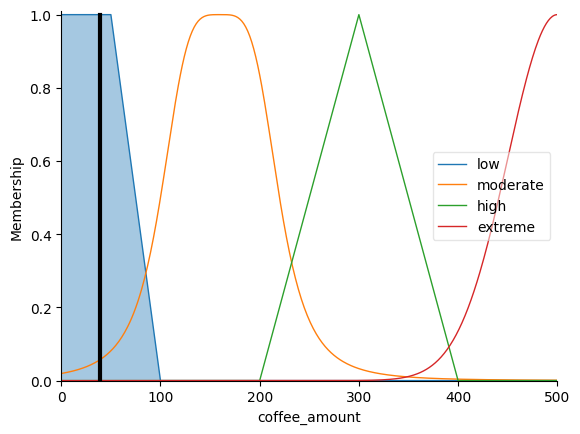

In [10]:

# === Правила ===
rules = [
    # Якщо людина спала недавно (fresh), завдання легке (easy), і вона у стабільному психологічному стані (stable), тоді низька доза кави (low).
    ctrl.Rule(no_sleep_hours['fresh'] & task_difficulty['easy'] & brain_crash['stable'], coffee_amount['low']),
    
    # Якщо людина дещо втомлена (tired), виконує завдання середньої складності (medium), і вже певний час працює (coding — medium), 
    # тоді слід випити помірну дозу кави (moderate).
    ctrl.Rule(no_sleep_hours['tired'] & task_difficulty['medium'] & coding_hours['medium'], coffee_amount['moderate']),
    
    # Якщо людина у зомбі-стані (zombie) або повністю вигоріла (panic), тоді потрібна максимальна доза кави (extreme).
    ctrl.Rule(no_sleep_hours['zombie'] | brain_crash['panic'], coffee_amount['extreme']),
    
    # Якщо дедлайн дуже близький (urgent), а психіка вже на межі (fragile), тоді потрібна висока доза кави (high).
    ctrl.Rule(deadline_pressure['urgent'] & brain_crash['fragile'], coffee_amount['high']),
    
    # Якщо завдання максимально складне (brainfuck), і кодить людина дуже довго (marathon), то потрібно багато кави (extreme).
    ctrl.Rule(task_difficulty['brainfuck'] & coding_hours['marathon'], coffee_amount['extreme']),
    
    # Якщо людина втомлена (tired), дедлайн наближається (soon), і стан психіки нестабільний (fragile), тоді потрібна висока доза кави (high).
    ctrl.Rule(no_sleep_hours['tired'] & deadline_pressure['soon'] & brain_crash['fragile'], coffee_amount['high']),
    
    # Якщо тільки сіла працювати (short coding), завдання просте (easy), і вона ще свіжа (fresh), тоді низька доза кави (low).
    ctrl.Rule(coding_hours['short'] & task_difficulty['easy'] & no_sleep_hours['fresh'], coffee_amount['low']),
    
    # Якщо немає жодного тиску по дедлайнах (none), людина стабільна (stable) і нещодавно спала (fresh), то низька доза кави (low).
    ctrl.Rule(deadline_pressure['none'] & brain_crash['stable'] & no_sleep_hours['fresh'], coffee_amount['low']),
    
    # Якщо людина довго кодить (marathon), завдання середньої складності, але вона все ще у стабільному стані, то вистачить помірної дози кави (moderate).
    ctrl.Rule(coding_hours['marathon'] & task_difficulty['medium'] & brain_crash['stable'], coffee_amount['moderate']),
    
    # Якщо не спав давно (zombie), дедлайн не горить (none), але людина ще стабільна — краще просто випити високу дозу кави (high), а не передоз.
    ctrl.Rule(no_sleep_hours['zombie'] & deadline_pressure['none'] & brain_crash['stable'], coffee_amount['high']),
]


# === Система управління ===
coffee_ctrl = ctrl.ControlSystem(rules)
coffee_sim = ctrl.ControlSystemSimulation(coffee_ctrl)

# === Приклад ===

coffee_sim.input['no_sleep_hours'] = 0
coffee_sim.input['coding_hours'] = 0
coffee_sim.input['task_difficulty'] = 1
coffee_sim.input['brain_crash'] = 1
coffee_sim.input['deadline_pressure'] = 1


coffee_sim.compute()
result = coffee_sim.output['coffee_amount']

print(f"\n☕ Рекомендована кількість кави: {round(result)} мл")
coffee_amount.view(sim=coffee_sim)

Варіант 1:
  no_sleep_hours = 1
  coding_hours = 1
  task_difficulty = 1
  brain_crash = 1
  deadline_pressure = 1
  ☕ Рекомендована кількість кави: 39 мл


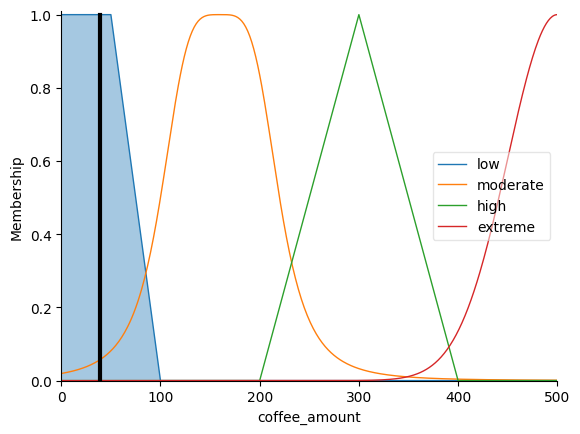

--------------------------------------------------
Варіант 2:
  no_sleep_hours = 6
  coding_hours = 4
  task_difficulty = 6
  brain_crash = 3
  deadline_pressure = 7
  ☕ Рекомендована кількість кави: 300 мл


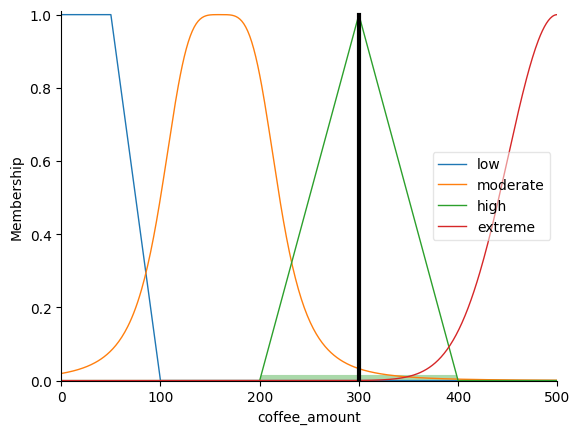

--------------------------------------------------
Варіант 3:
  no_sleep_hours = 9
  coding_hours = 5
  task_difficulty = 4
  brain_crash = 3
  deadline_pressure = 6
  ☕ Рекомендована кількість кави: 139 мл


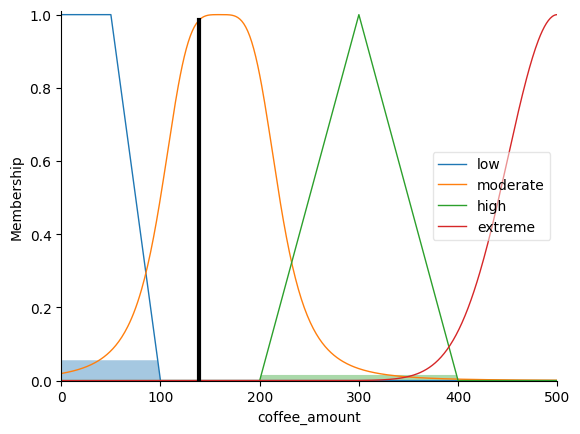

--------------------------------------------------
Варіант 4:
  no_sleep_hours = 18
  coding_hours = 12
  task_difficulty = 6
  brain_crash = 8
  deadline_pressure = 8
  ☕ Рекомендована кількість кави: 366 мл


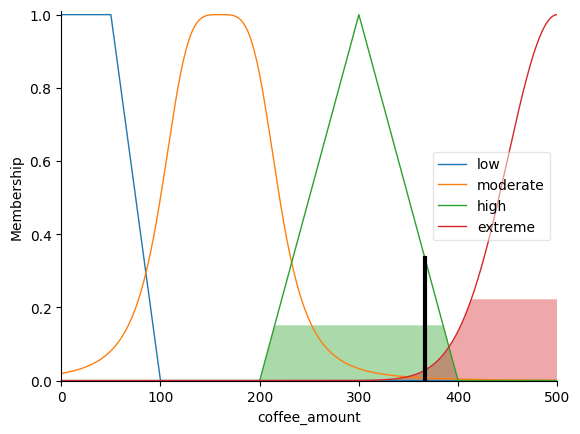

--------------------------------------------------
Варіант 5:
  no_sleep_hours = 36
  coding_hours = 36
  task_difficulty = 10
  brain_crash = 10
  deadline_pressure = 10
  ☕ Рекомендована кількість кави: 459 мл


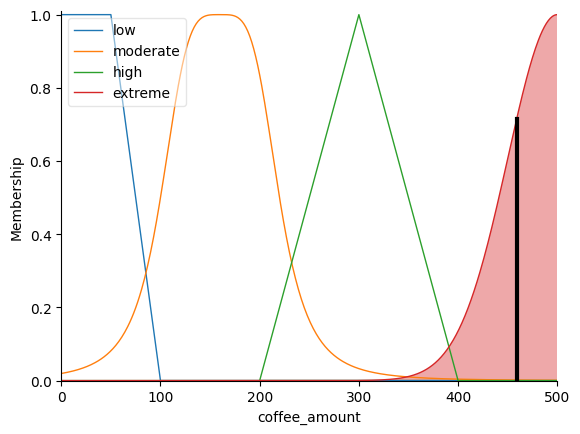

--------------------------------------------------


In [11]:
test_cases = [
    {'no_sleep_hours': 1, 'coding_hours': 1, 'task_difficulty': 1, 'brain_crash': 1, 'deadline_pressure': 1},
    {'no_sleep_hours': 6, 'coding_hours': 4, 'task_difficulty': 6, 'brain_crash': 3, 'deadline_pressure': 7},
    {'no_sleep_hours': 9, 'coding_hours': 5, 'task_difficulty': 4, 'brain_crash': 3, 'deadline_pressure': 6},
    {'no_sleep_hours': 18, 'coding_hours': 12, 'task_difficulty': 6, 'brain_crash': 8, 'deadline_pressure': 8},
    {'no_sleep_hours': 36, 'coding_hours': 36, 'task_difficulty': 10, 'brain_crash': 10, 'deadline_pressure': 10},
]


for i, case in enumerate(test_cases, start=1):
    for key, value in case.items():
        coffee_sim.input[key] = value

    coffee_sim.compute()
    result = coffee_sim.output['coffee_amount']

    print(f"Варіант {i}:")
    print(f"  no_sleep_hours = {case['no_sleep_hours']}")
    print(f"  coding_hours = {case['coding_hours']}")
    print(f"  task_difficulty = {case['task_difficulty']}")
    print(f"  brain_crash = {case['brain_crash']}")
    print(f"  deadline_pressure = {case['deadline_pressure']}")
    print(f"  ☕ Рекомендована кількість кави: {round(result)} мл")
    coffee_amount.view(sim=coffee_sim)
    plt.show()
    print("-" * 50)